In [14]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI and machine learning/FruitinAmazon.zip'
extraction_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}' successfully.")
print(f"Contents of the extraction directory: {os.listdir(extraction_path)}")

'/content/drive/MyDrive/AI and machine learning/FruitinAmazon.zip' unzipped to './' successfully.
Contents of the extraction directory: ['.config', 'drive', 'FruitinAmazon', 'sample_data']


In [15]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

train_dir = '/content/FruitinAmazon/train'
test_dir  = '/content/FruitinAmazon/test'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Task 1: Data understanding and visualization

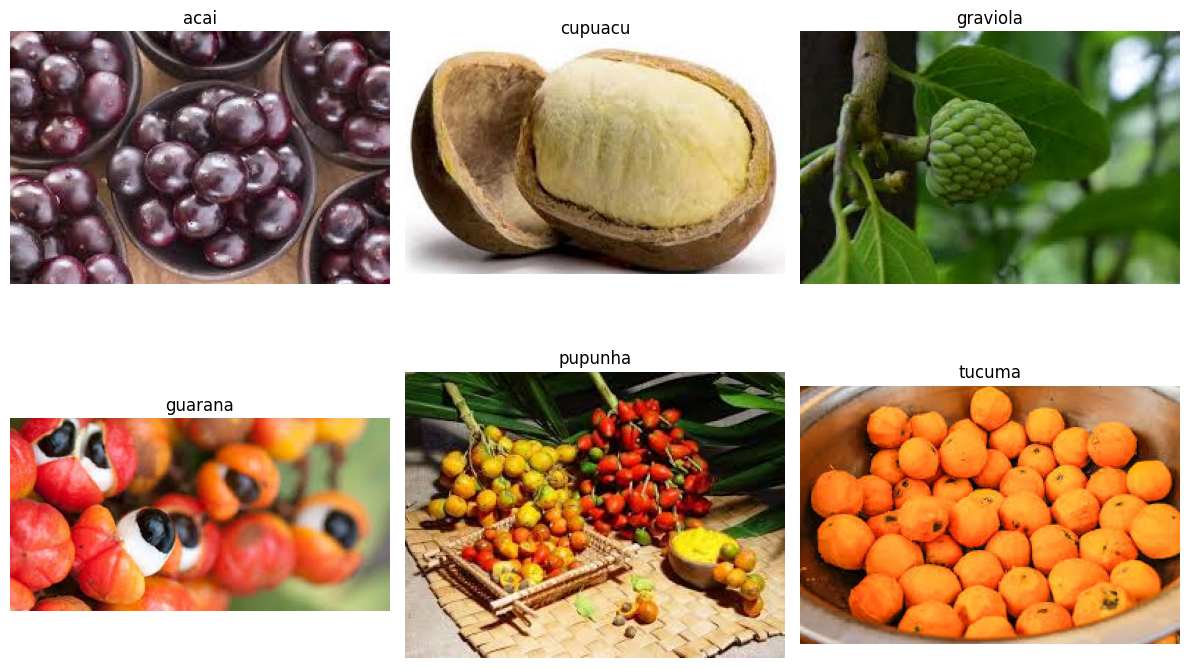

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Observation: Images vary in size, background, and lighting across classes.


In [16]:
# Task 1.1 - Visualise one random image per class in a 2-row grid
class_dirs = sorted(os.listdir(train_dir))
num_classes = len(class_dirs)

cols = (num_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for i, cls in enumerate(class_dirs):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    img_path = os.path.join(cls_path, random.choice(images))  # random sample
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print(f"Classes found: {class_dirs}")
print("Observation: Images vary in size, background, and lighting across classes.")

# Task 1: Check corrupted images

In [17]:
# Task 1.2 - Check for and remove corrupted images
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [18]:
# Hyperparameters
img_height      = 128
img_width       = 128
batch_size      = 16
validation_split = 0.2

# Normalise pixel values to [0, 1]
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test dataset (no split, full folder)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print(f"Number of classes: {num_classes}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Number of classes: 6


In [19]:
# CNN architecture
model = keras.Sequential([

    # Conv Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Conv Block 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # Flatten and fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),  # hidden layer 1
    layers.Dense(64,  activation='relu'),  # hidden layer 2

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
# Callbacks: save best model and stop early if no improvement
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.1653 - loss: 2.2581
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 388ms/step - accuracy: 0.1389 - loss: 2.3655 - val_accuracy: 0.0000e+00 - val_loss: 1.9016
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.3049 - loss: 1.6568
Epoch 2: val_accuracy improved from 0.00000 to 0.16667, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step - accuracy: 0.3056 - loss: 1.6459 - val_accuracy: 0.1667 - val_loss: 1.6161
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.3993 - loss: 1.5463
Epoch 3: val_accuracy improved from 0.16667 to 0.61111, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 339ms/step - accuracy: 0.4444 - loss: 1.4572 - val_accuracy: 0.6111 - val_loss: 1.2279
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.5733 - loss: 1.1659
Epoch 4: val_accuracy did not improve from 0.61111
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 469ms/step - accuracy: 0.6111 - loss: 1.1184 - val_accuracy: 0.3333 - val_loss: 1.1667
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8184 - loss: 0.7787
Epoch 5: val_accuracy improved from 0.61111 to 0.72222, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 544ms/step - accuracy: 0.8056 - loss: 0.7543 - val_accuracy: 0.7222 - val_loss: 0.7960
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.8885 - loss: 0.4565
Epoch 6: val_accuracy improved from 0.72222 to 0.77778, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 356ms/step - accuracy: 0.8750 - loss: 0.4631 - val_accuracy: 0.7778 - val_loss: 0.4985
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9719 - loss: 0.1681
Epoch 7: val_accuracy improved from 0.77778 to 0.83333, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 336ms/step - accuracy: 0.9583 - loss: 0.2152 - val_accuracy: 0.8333 - val_loss: 0.4106
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9840 - loss: 0.1133
Epoch 8: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 453ms/step - accuracy: 0.9722 - loss: 0.1175 - val_accuracy: 0.8333 - val_loss: 0.4240
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 1.0000 - loss: 0.0511
Epoch 9: val_accuracy improved from 0.83333 to 0.88889, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 535ms/step - accuracy: 1.0000 - loss: 0.0592 - val_accuracy: 0.8889 - val_loss: 0.2436
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 1.0000 - loss: 0.0301
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 1.0000 - loss: 0.0424 - val_accuracy: 0.8333 - val_loss: 0.3732
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9872 - loss: 0.0268
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 513ms/step - accuracy: 0.9722 - loss: 0.0476 - val_accuracy: 0.8333 - val_loss: 0.4140
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9941 - loss: 0.0733
Epoch 12: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 527ms/step - accuracy: 0.9861 - loss: 0.1674 - val_accuracy: 0.8889 - val_loss: 0.6331
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.9712 - loss

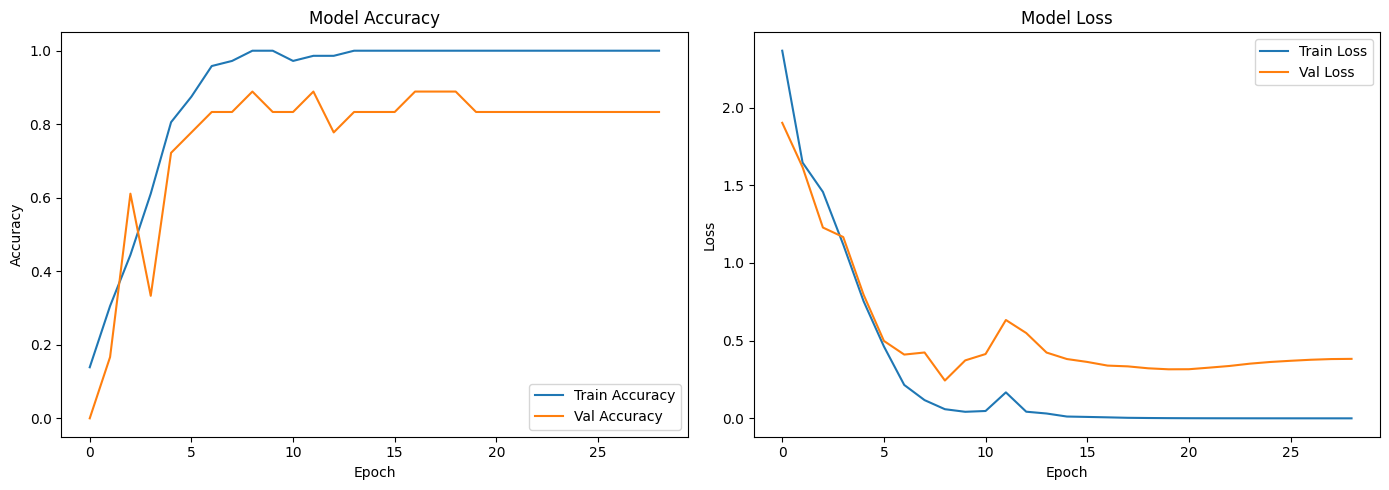

In [23]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Task 5: Evaluate on test set

In [24]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.6333 - loss: 0.8876
Test Loss:     0.8876
Test Accuracy: 0.6333


In [25]:
model.save('cnn_fruits_model.h5')
print("Model saved as cnn_fruits_model.h5")

# Load and re-evaluate to confirm it saved correctly
loaded_model = keras.models.load_model('cnn_fruits_model.h5')
loss, acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model - Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

Model saved as cnn_fruits_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.6333 - loss: 0.8876
Loaded Model - Test Loss: 0.8876 | Test Accuracy: 0.6333


# Task 7: Predictions and classification report

In [26]:
# Collect all true labels and predictions from test set
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_dirs))

              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.42      1.00      0.59         5
     guarana       0.67      0.80      0.73         5
     pupunha       1.00      0.40      0.57         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.63        30
   macro avg       0.76      0.63      0.63        30
weighted avg       0.76      0.63      0.63        30

